# IT2011 — Progress Review I: Group Pipeline
### Combined Preprocessing Pipeline (Shared, 5 marks)
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) — 569 records, 30 features, 2 classes (Benign / Malignant)
**Group ID:** 2026-Y2-S1-IT2011

This notebook **integrates every member's individual technique** in the correct logical order, on the full dataset, producing one final clean, encoded, outlier-trimmed, scaled dataset ready for modelling.

| Step | Technique | Owner |
|---|---|---|
| 1 | Missing data check/imputation | IT25103807 |
| 2 | Label encoding (target) | IT25103810 |
| 3 | IQR outlier removal | IT25103808 |
| 4 | StandardScaler | IT25103755 |
| 5 | Redundant feature removal | IT25103809 |
| 6 | PCA (2D, visualization) | IT25103812 |

**Pipeline order (and why):** Load data → check/handle missing values → encode target → remove outliers → drop redundant features → scale features → (optional) PCA for visualization.

> Scaling is deliberately done **after** outlier removal and redundant-feature dropping — scaling parameters (mean/std) should be computed on the data we're actually going to model with, not on rows/columns we're about to discard.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ---- Load dataset ----
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "target_sklearn"}, inplace=True)
df["diagnosis"] = df["target_sklearn"].map({0: "M", 1: "B"})
df.drop(columns=["target_sklearn"], inplace=True)

feature_cols = [c for c in df.columns if c != "diagnosis"]

print("Shape:", df.shape)
df.head()

# ---- Alternative: load from the raw UCI CSV placed in data/raw/ ----
# df = pd.read_csv("data/raw/wdbc.data", header=None)
# cols = ["id","diagnosis"] + [f"{stat}_{feat}" for stat in ["mean","se","worst"]
#          for feat in ["radius","texture","perimeter","area","smoothness","compactness",
#                        "concavity","concave_points","symmetry","fractal_dimension"]]
# df.columns = cols
# df.drop(columns=["id"], inplace=True)


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [2]:
def iqr_outlier_report(frame, cols):
    report = {}
    for c in cols:
        q1, q3 = frame[c].quantile(0.25), frame[c].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = frame[(frame[c] < low) | (frame[c] > high)].shape[0]
        report[c] = n_out
    return pd.Series(report).sort_values(ascending=False)


In [3]:
def run_group_pipeline(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Combined preprocessing pipeline — integrates all 6 members' work."""
    d = raw_df.copy()
    feats = [c for c in d.columns if c not in ["diagnosis", "diagnosis_encoded"]]

    # --- Step 1 (Member 1 - IT25103807): missing value check + safeguard imputation ---
    if d[feats].isnull().sum().sum() > 0:
        d[feats] = SimpleImputer(strategy="mean").fit_transform(d[feats])
    else:
        print("Step 1 [Missing data]: none found — no imputation needed.")

    # --- Step 2 (Member 2 - IT25103810): encode target ---
    le_ = LabelEncoder()
    d["diagnosis_encoded"] = le_.fit_transform(d["diagnosis"])
    print("Step 2 [Encoding]: diagnosis ->", dict(zip(le_.classes_, le_.transform(le_.classes_))))

    # --- Step 3 (Member 3 - IT25103808): IQR outlier removal on top-3 flagged features ---
    outl_counts = iqr_outlier_report(d, feats)
    top3 = outl_counts.head(3).index.tolist()
    before = d.shape[0]
    for c in top3:
        q1, q3 = d[c].quantile(0.25), d[c].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        d = d[(d[c] >= low) & (d[c] <= high)]
    print(f"Step 3 [Outliers]: removed {before - d.shape[0]} rows using {top3}")

    # --- Step 4 (Member 5 - IT25103809): drop redundant (|r| > 0.95) features ---
    corr = d[feats].corr()
    drop_set = set()
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.95:
                f1, f2 = corr.columns[i], corr.columns[j]
                drop_set.add(f2 if "mean" in f1 or "mean" not in f2 else f1)
    feats_reduced = [c for c in feats if c not in drop_set]
    print(f"Step 4 [Redundant features]: {len(feats)} -> {len(feats_reduced)} features "
          f"(dropped {len(drop_set)})")

    # --- Step 5 (Member 4 - IT25103755): scale remaining features ---
    scaler_ = StandardScaler()
    scaled = scaler_.fit_transform(d[feats_reduced])
    d_final = pd.DataFrame(scaled, columns=feats_reduced, index=d.index)
    d_final["diagnosis_encoded"] = d["diagnosis_encoded"].values
    d_final["diagnosis"] = d["diagnosis"].values

    return d_final

df_pipeline_ready = run_group_pipeline(df)
print("\nFinal pipeline output shape:", df_pipeline_ready.shape)
df_pipeline_ready.head()

Step 1 [Missing data]: none found — no imputation needed.
Step 2 [Encoding]: diagnosis -> {'B': np.int64(0), 'M': np.int64(1)}
Step 3 [Outliers]: removed 81 rows using ['area error', 'radius error', 'perimeter error']
Step 4 [Redundant features]: 30 -> 25 features (dropped 5)

Final pipeline output shape: (488, 27)


,mean radius,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,...,fractal dimension error,worst texture,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis_encoded,diagnosis
1,2.675174,-0.270549,-0.745612,-0.361763,0.236743,1.020785,0.104884,-0.894633,1.780976,-0.829236,...,-0.011237,-0.302874,-0.333046,-0.335861,-0.012195,1.428004,-0.211816,0.299957,1,M
3,-0.681928,0.342475,3.339240,4.117526,2.654757,2.188563,3.145046,5.056074,1.402058,-0.041538,...,2.507750,0.202940,3.350369,4.138039,2.230887,2.643316,6.143556,4.891935,1,M
5,-0.304025,-0.756740,2.299640,1.631942,1.346369,1.378153,1.169909,1.945710,0.127659,-0.537558,...,0.676647,-0.247218,2.035476,1.890887,1.468249,1.225736,1.806930,2.234515,1,M
6,1.823974,0.248525,-0.046180,0.300768,0.640528,1.148464,0.035173,-0.785164,1.015229,-0.755896,...,-0.611693,0.392825,0.540694,0.131473,0.676899,1.550385,0.299817,0.007969,1,M
7,0.158265,0.448168,1.670222,1.511918,0.342541,0.676752,1.592046,1.709258,2.097401,0.370878,...,0.823100,0.471398,1.448699,0.859461,0.119780,0.911284,0.517221,1.725996,1,M


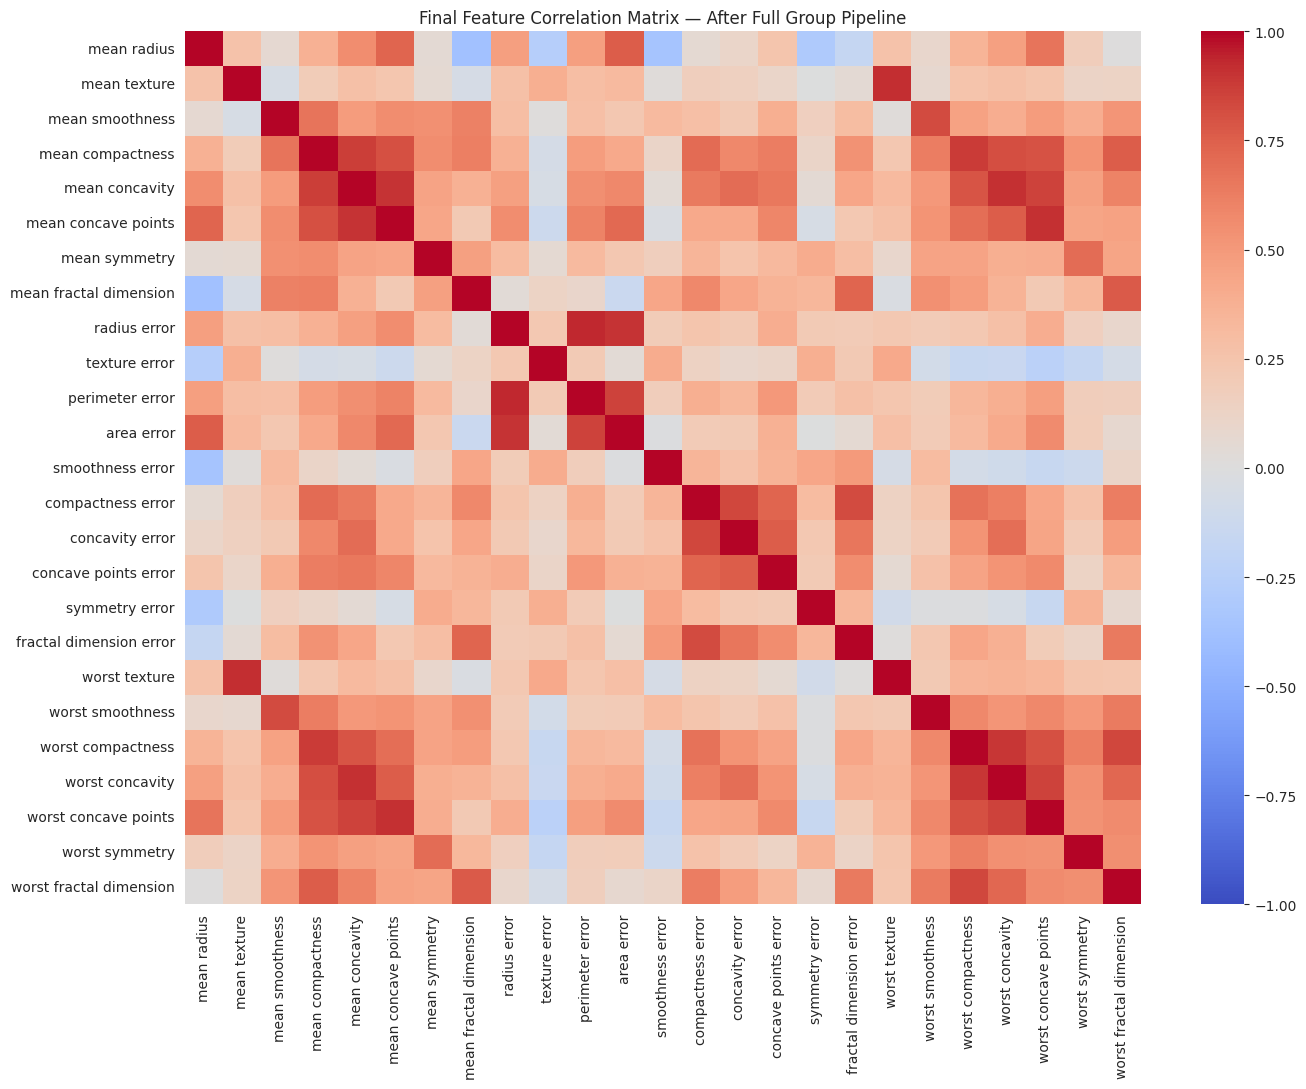

In [4]:
# ---- Group-level EDA: final correlation matrix after redundancy removal ----
final_feats = [c for c in df_pipeline_ready.columns if c not in ["diagnosis", "diagnosis_encoded"]]
plt.figure(figsize=(14, 11))
sns.heatmap(df_pipeline_ready[final_feats].corr(), cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True)
plt.title("Final Feature Correlation Matrix — After Full Group Pipeline")
plt.tight_layout()
plt.show()

**Interpretation:** Compared to the raw 30-feature correlation matrix, the strongest (>0.97) redundant blocks are gone, leaving a cleaner, still-informative feature set. This final, scaled, encoded, outlier-trimmed dataframe (`df_pipeline_ready`) is what should be exported to `results/outputs/` and used as the direct input to the modelling stage.

Optionally, PCA (Member 6's technique) can be applied on top of `df_pipeline_ready` purely for a 2D visualization check — see the PCA member notebook for that step in isolation.


In [5]:
import os
os.makedirs("results/outputs", exist_ok=True)
df_pipeline_ready.to_csv("results/outputs/processed_breast_cancer.csv", index=False)
print("Saved final processed dataset to results/outputs/processed_breast_cancer.csv")
print("Final shape:", df_pipeline_ready.shape)

Saved final processed dataset to results/outputs/processed_breast_cancer.csv
Final shape: (488, 27)


---
## Summary Table (for the viva)

| Step | Technique | Owner | Cols in → out |
|---|---|---|---|
| 1 | Missing data check/imputation | IT25103807 | 30 → 30 |
| 2 | Label encoding (target) | IT25103810 | 30 → 31 |
| 3 | IQR outlier removal | IT25103808 | rows reduced |
| 4 | Redundant feature removal | IT25103809 | 30 → ~2x |
| 5 | StandardScaler | IT25103755 | unchanged shape |
| 6 | PCA (2D, separate demo) | IT25103812 | visualization-only |

*(Exact row/column counts print when you run the notebook.)*
